# In this notebook we are going to train / evaluate different ML models #

## prior to train a model we are pre processing audio files ##
## ML models ##
- *VGGNET (CONV2D) Baseline*
- *Improved (Regularized VGGNET)*
- *Transfer Learning*
    - *EfficientNetB0*
    - *VGGish*

### Mount Drive ###

In [1]:
from google.colab import drive
import os

DRIVE_PATH = '/content/drive'
drive.mount(DRIVE_PATH)
MYDRIVE_PATH = os.path.join(DRIVE_PATH, 'MyDrive/')
TARGET_DIR = os.path.join(MYDRIVE_PATH, 'dsfs-ft-31', 'alzheimer_data/')
TRAIN_AUDIOS_WAV_DIR = os.path.join(TARGET_DIR , 'train_audios','wav/')
print(f'TRAIN_AUDIOS_WAV_DIR : {TRAIN_AUDIOS_WAV_DIR}')
TEST_AUDIOS_WAV_DIR = os.path.join(TARGET_DIR, 'test_audios','wav/')
LABELS_DIR = os.path.join(TARGET_DIR, 'labels/')
TRAIN_LABELS_FILE_PATH = LABELS_DIR + 'train_labels.csv'
print(f'TRAIN_LABELS_FILE_PATH : {TRAIN_LABELS_FILE_PATH}')
TEST_LABELS_FILE_PATH = LABELS_DIR + 'test_labels.csv'

Mounted at /content/drive
TRAIN_AUDIOS_WAV_DIR : /content/drive/MyDrive/dsfs-ft-31/alzheimer_data/train_audios/wav/
TRAIN_LABELS_FILE_PATH : /content/drive/MyDrive/dsfs-ft-31/alzheimer_data/labels/train_labels.csv


### Imports ###

In [2]:
import os
import numpy as np
import pandas as pd
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
import librosa


# Deep Learning
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.image import resize
from tensorflow.keras.models import load_model
from tensorflow.keras.losses import CategoricalCrossentropy

# Data Visualization
import librosa.display
import matplotlib.pyplot as plt

# Image Processing
from skimage.transform import resize

### Define constants and load labels ###

In [3]:
labels_file = TRAIN_LABELS_FILE_PATH  # Path to CSV file
audio_dir = TRAIN_AUDIOS_WAV_DIR    # Path to audio files

# Load labels
labels_df = pd.read_csv(labels_file)

# Get classes (diagnosis_control, diagnosis_mci, diagnosis_adrd)
CLASSES_NAMES = ['diagnosis_control', 'diagnosis_mci', 'diagnosis_adrd']

### Check ###

In [4]:
print(type(labels_df))
print(labels_df.shape)
print(labels_df.columns)
print(labels_df.head())

print("Train label distribution:")
print(labels_df["diagnosis_control"].value_counts(normalize=True))
print(labels_df["diagnosis_mci"].value_counts(normalize=True))
print(labels_df["diagnosis_adrd"].value_counts(normalize=True))

<class 'pandas.core.frame.DataFrame'>
(1646, 4)
Index(['uid', 'diagnosis_control', 'diagnosis_mci', 'diagnosis_adrd'], dtype='object')
    uid  diagnosis_control  diagnosis_mci  diagnosis_adrd
0  aaop                0.0            1.0             0.0
1  abgk                1.0            0.0             0.0
2  ablf                1.0            0.0             0.0
3  acad                1.0            0.0             0.0
4  acis                0.0            1.0             0.0
Train label distribution:
diagnosis_control
1.0    0.553463
0.0    0.446537
Name: proportion, dtype: float64
diagnosis_mci
0.0    0.868165
1.0    0.131835
Name: proportion, dtype: float64
diagnosis_adrd
0.0    0.685298
1.0    0.314702
Name: proportion, dtype: float64


### Audio  data - Pre processing methods ###

In [5]:

SAMPLING_RATE = 16000
TARGET_SHAPE =(96, 1366)
TARGET_DURATION = 30.0
MIN_DURATION = 25.0
TOP_THRESHOLD_DB = 30.0

N_MELS = 128
N_FFT = 1024
HOP_LENGTH = 256
FREQ_MIN = 20
FREQ_MAX = 8000

DURATION_MIN_THRESHOLD = 1.0

APPLY_AUDIO_AUGMENTATION = True

def trim_silence(audio_data:np.ndarray, top_threshold_db:float) -> np.ndarray:
  '''
  Remove silences (zones with very low energy) at the beginning and at the end of array
  '''
  if audio_data is None or len(audio_data) == 0:
      return audio_data

  audio_data_trimmed, _ = librosa.effects.trim(audio_data, top_db=top_threshold_db)
  return audio_data_trimmed


def normalize_audio_by_max(audio_data:np.ndarray)-> np.ndarray:
  '''
  Normalize audio data so max equals 1 - normalize volume differences between audio / patients
  '''
  if audio_data is None or len(audio_data) == 0:
      return audio_data
  max_val = np.max(np.abs(audio_data))
  if max_val < 1e-6:
      return audio_data
  audio_data_normalized = audio_data / max_val
  return audio_data_normalized


def pad_audio(audio_data:np.ndarray, sampling_rate:float, target_duration:float)-> np.ndarray:
    """
    Add silence at the end of the audio file if its duration is less than target_duration.
    Does not cut the audio if its duration is greater than target_duration.
    """
    target_length = int(target_duration * sampling_rate)
    if len(audio_data) < target_length:
        padding_length = target_length - len(audio_data)
        audio_data = np.pad(audio_data, (0, padding_length), mode='constant')
    return audio_data


import random

def augment_audio(audio_data: np.ndarray, sampling_rate: int) -> np.ndarray:
    """
    Apply random data augmentations to audio signal.
    """

    # Slight time shifting
    # Simulate the fact that an audio recording starts before or after.
    if random.random() < 0.3:
        shift = int(random.uniform(-0.1, 0.1) * len(audio_data))
        audio_data = np.roll(audio_data, shift)

    # Pitch shifting
    # Helps model not basing on voice pitch only
    if random.random() < 0.3:
        n_steps = random.uniform(-1.0, 1.0)
        audio_data = librosa.effects.pitch_shift(audio_data, sr=sampling_rate, n_steps=n_steps)

  # Time stretching
  # Simulate speech rate
    if random.random() < 0.3:
        rate = random.uniform(0.9, 1.1)
        audio_data = librosa.effects.time_stretch(audio_data, rate=rate)

  # Add noise
    if random.random() < 0.3:
        noise_amp = 0.005 * np.random.uniform() * np.amax(audio_data)
        audio_data = audio_data + noise_amp * np.random.normal(size=audio_data.shape)

    return audio_data


def extract_mel_spectrogram(audio_data_normalized:np.ndarray, sampling_rate:float) -> np.ndarray:
    """
    Extract mel-spectrogram features from an audio signal.
    temporal domain to time-frequency domain
    """

    mel_spectrogram = librosa.feature.melspectrogram(
        y=audio_data_normalized,
        sr=sampling_rate,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        n_mels=N_MELS,
        fmin=FREQ_MIN,
        fmax=FREQ_MAX
    )

    mel_db = librosa.power_to_db(mel_spectrogram, ref=np.max)

    # Min-max normalization for neural networks. It improves gradient descent robustness
    mel_db -= mel_db.min()
    mel_db /= mel_db.max() + 1e-6

    return mel_db


def resize_spectrogram(mel_db:np.ndarray, target_shape:tuple[int,int]) -> np.ndarray:
    """
    Redims mel-spectogram to target_shape
    """
    mel_resized = resize(mel_db, target_shape, mode='reflect',anti_aliasing=True)
    # Expend dim (add channel dim)
    mel_resized = np.expand_dims(mel_resized, axis=-1)
    return mel_resized


def preprocess_audio_file(audio_file_path:str,apply_augmentation: bool = False) -> tuple[np.ndarray, float, float]:
    audio_data, sr = librosa.load(audio_file_path, sr=SAMPLING_RATE)
    audio_data = trim_silence(audio_data, top_threshold_db=TOP_THRESHOLD_DB)
    audio_data = normalize_audio_by_max(audio_data)

    duration_original = librosa.get_duration(y=audio_data, sr=sr)

    if duration_original < MIN_DURATION:
        return None, duration_original, 0.0

    if apply_augmentation:
        if random.random() < 0.5:  #50 % of audio files
            audio_data = augment_audio(audio_data, sr)

    audio_data = pad_audio(audio_data, sr, TARGET_DURATION)
    duration_final = librosa.get_duration(y=audio_data, sr=sr)

    mel_spectrogram = extract_mel_spectrogram(audio_data, sr)
    mel_spectrogram = resize_spectrogram(mel_spectrogram, TARGET_SHAPE)

    return (mel_spectrogram, duration_original, duration_final)


def load_and_preprocess_data(audio_dir: str, labels_df,apply_augmentation: bool):
    data = []
    labels = []
    durations_original = []
    durations_final = []
    dropped_count = 0

    for _, row in labels_df.iterrows():
        file_path = os.path.join(audio_dir, f"{row['uid']}.wav")
        if not os.path.exists(file_path):
            print(f"Missing audio file: {file_path}")
            continue

        mel_spectrogram, duration_original, duration_final = preprocess_audio_file(file_path,apply_augmentation=apply_augmentation)
        if mel_spectrogram is None:
            print(f"Skipping short audio: {file_path} ({duration_original:.2f} s)")
            dropped_count += 1
            continue

        data.append(mel_spectrogram)
        labels.append([row['diagnosis_control'], row['diagnosis_mci'], row['diagnosis_adrd']])
        durations_original.append(duration_original)
        durations_final.append(duration_final)

    print(f"\n{len(data)} files successfully pre-processed")
    print(f"{dropped_count} files too short (< {MIN_DURATION}s) ignored\n")

    return np.array(data), np.array(labels), dropped_count, durations_original, durations_final


### Run preprocessing ###

In [7]:
#Start by doing train_test_split since train and val pre-processing might differ
TEST_PROP = 0.2

labels_df["class_id"] = labels_df[["diagnosis_control", "diagnosis_mci", "diagnosis_adrd"]].idxmax(axis=1)

train_labels_df, val_labels_df = train_test_split(
    labels_df,
    test_size=TEST_PROP,
    random_state=42,
    stratify=labels_df["class_id"]
)

print("Train label distribution:")
print(train_labels_df["class_id"].value_counts(normalize=True))

print("\nValidation label distribution:")
print(val_labels_df["class_id"].value_counts(normalize=True))


print('--------------- start TRAIN set pre-processing ----------- ')
X_train, y_train, dropped_train, dur_train_orig, dur_train_final = load_and_preprocess_data(
    audio_dir=TRAIN_AUDIOS_WAV_DIR,
    labels_df=train_labels_df,
    apply_augmentation=False
)

print(f"Number of files after filtering : {len(X_train)}")
print(f"Number of files ignored (too short) : {dropped_train}")
print(f"X Shape : {X_train.shape}")
print(f"y Shape : {y_train.shape}")

num_padded = sum([1 for orig, final in zip(dur_train_orig, dur_train_final) if final > orig])
print(f"Number of files that were padded: {num_padded}")

print(y_train[:2,:])

print('--------------- start VAL set pre-processing ----------- ')
X_val, y_val, dropped_val, dur_val_orig, dur_val_final = load_and_preprocess_data(
    audio_dir=TRAIN_AUDIOS_WAV_DIR,
    labels_df=val_labels_df,
    apply_augmentation=False
)

print(f"Number of files after filtering : {len(X_val)}")
print(f"Number of files ignored (too short) : {dropped_val}")
print(f"X Shape : {X_val.shape}")
print(f"y Shape : {y_val.shape}")

num_padded = sum([1 for orig, final in zip(dur_val_orig, dur_val_final) if final > orig])
print(f"Number of files that were padded: {num_padded}")

print(y_val[:2,:])



Train label distribution:
class_id
diagnosis_control    0.553191
diagnosis_adrd       0.314590
diagnosis_mci        0.132219
Name: proportion, dtype: float64

Validation label distribution:
class_id
diagnosis_control    0.554545
diagnosis_adrd       0.315152
diagnosis_mci        0.130303
Name: proportion, dtype: float64
--------------- start TRAIN set pre-processing ----------- 
Skipping short audio: /content/drive/MyDrive/dsfs-ft-31/alzheimer_data/train_audios/wav/lwxg.wav (24.25 s)
Skipping short audio: /content/drive/MyDrive/dsfs-ft-31/alzheimer_data/train_audios/wav/blyu.wav (21.67 s)
Skipping short audio: /content/drive/MyDrive/dsfs-ft-31/alzheimer_data/train_audios/wav/tipu.wav (23.14 s)
Skipping short audio: /content/drive/MyDrive/dsfs-ft-31/alzheimer_data/train_audios/wav/blde.wav (17.30 s)
Skipping short audio: /content/drive/MyDrive/dsfs-ft-31/alzheimer_data/train_audios/wav/jxrc.wav (23.01 s)
Skipping short audio: /content/drive/MyDrive/dsfs-ft-31/alzheimer_data/train_audios

X Shape : (batch_size, 96, 1366, 1)

For train
-----
1010 : dataset size
96 : number of lines in mel spectogram (frequencies)
1366 : number of temporal frames (number of columns - time)
1 : number of channels (mono)

### Create TRAIN and VAL Tf dataset with batch ###

In [7]:
np.unique(np.argmax(y_train, axis=1), return_counts=True)

(array([0, 1, 2]), array([555, 144, 311]))

### Check class distribution in y_train and y_val ###

In [8]:
import numpy as np

counts = np.sum(y_train, axis=0)
for i, c in enumerate(counts):
    print(f"Classe {i} : {int(c)} exemples ({c / np.sum(counts) * 100:.2f}%)")


Classe 0 : 555 exemples (54.95%)
Classe 1 : 144 exemples (14.26%)
Classe 2 : 311 exemples (30.79%)


In [9]:
import numpy as np

counts = np.sum(y_val, axis=0)
for i, c in enumerate(counts):
    print(f"Classe {i} : {int(c)} exemples ({c / np.sum(counts) * 100:.2f}%)")

Classe 0 : 143 exemples (57.66%)
Classe 1 : 30 exemples (12.10%)
Classe 2 : 75 exemples (30.24%)


In [10]:
print("y_train.shape:", y_train.shape)
print("Exemples de y_train[:5]:\n", y_train[:5])

y_train.shape: (1010, 3)
Exemples de y_train[:5]:
 [[1. 0. 0.]
 [0. 0. 1.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 0. 1.]]


In [88]:
BATCH_SIZE = 64

train_ds = (tf.data.Dataset.from_tensor_slices((X_train, y_train))
  .shuffle(len(X_train))
  .batch(BATCH_SIZE)
  .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices((X_val, y_val))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)


### Model evaluation metrics methods ###

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix,classification_report

def display_confusion_matrix(conf_matrix, class_names):
  plt.figure(figsize=(6, 5))
  sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
  plt.xlabel('Predicted Label')
  plt.ylabel('True Label')
  plt.title('Confusion Matrix')
  plt.show()


def print_classification_report(model:tf.keras.models.Model, X:np.ndarray, y:np.ndarray,class_names):
  y_pred = model.predict(X)
  y_pred_classes = np.argmax(y_pred, axis=1)
  y_true = np.argmax(y, axis=1)

  cm = confusion_matrix(y_true, y_pred_classes)
  print("Confusion matrix:\n")
  display_confusion_matrix(cm,class_names)
  print("\nClassification report:\n", classification_report(y_true, y_pred_classes, digits=3))



### Plot learning history methods ###

In [12]:

import plotly.graph_objects as go
from sklearn.metrics import accuracy_score, recall_score, f1_score, confusion_matrix as sklearn_confusion_matrix

def plot_training_accuracy_history(model_training_history):
  """
  model_training_history : keras.src.callbacks.history.History
  """
  fig = go.Figure()
  accuracy_key = "categorical_accuracy"
  if accuracy_key not in model_training_history.history.keys():
    accuracy_key = "accuracy"

  val_accuracy_key = "val_categorical_accuracy"
  if val_accuracy_key not in model_training_history.history.keys():
    val_accuracy_key = "val_accuracy"
  fig.add_trace(go.Scatter(y=model_training_history.history[accuracy_key],
                      mode='lines',
                      name='accuracy'))
  fig.add_trace(go.Scatter(y=model_training_history.history[val_accuracy_key],
                      mode='lines',
                      name='val_accuracy'))
  fig.update_layout(title='Training and Validation accuracy')
  fig.show()

### Baseline VGG ###

In [37]:

class VGGNet_Baseline_Model(tf.keras.models.Model):
    def __init__(self, classes:tuple[str, ...]):
        super(VGGNet_Baseline_Model, self).__init__()
        self.num_classes = len(classes)
        self.conv2D_1 = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same')
        self.maxPooling2D_1 = tf.keras.layers.MaxPooling2D((2, 4))
        self.conv2D_2 = tf.keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same')
        self.maxPooling2D_2 = tf.keras.layers.MaxPooling2D((2, 4))
        self.conv2D_3 = tf.keras.layers.Conv2D(512, (3, 3), activation='relu', padding='same')
        self.maxPooling2D_3 = tf.keras.layers.MaxPooling2D((2, 4))
        self.conv2D_4 = tf.keras.layers.Conv2D(1024, (3, 3), activation='relu', padding='same')
        self.maxPooling2D_4 = tf.keras.layers.MaxPooling2D((3, 5))
        self.conv2D_5 = tf.keras.layers.Conv2D(2048, (3, 3), activation='relu', padding='same')
        self.maxPooling2D_5 = tf.keras.layers.MaxPooling2D((4,4))
        self.conv2D_6 = tf.keras.layers.Conv2D(1024, (1,1), activation='relu', padding='same')

        # Fully connected layers
        self.flatten_1 = tf.keras.layers.Flatten()
        self.dense_head = tf.keras.layers.Dense(self.num_classes, activation='softmax')

    def call(self, inputs,training=False):
        x = self.conv2D_1(inputs)
        x = self.maxPooling2D_1(x)
        x = self.conv2D_2(x)
        x = self.maxPooling2D_2(x)
        x = self.conv2D_3(x)
        x = self.maxPooling2D_3(x)
        x= self.conv2D_4(x)
        x = self.maxPooling2D_4(x)
        x = self.conv2D_5(x)
        x = self.maxPooling2D_5(x)
        x = self.conv2D_6(x)
        x = self.flatten_1(x)
        x = self.dense_head(x)
        return x

def __str__(self):
    return f"VGGNet_Baseline_Model(num_classes={self.num_classes})"


### Define Learning process constants and instanciate baseline model ###

In [38]:
DROPOUT_RATE = 0.15
LEARNING_RATE = 0.001
BATCH_SIZE = 32
NUM_EPOCHS=25
CLASSES_NAMES = ('diagnosis_control', 'diagnosis_mci', 'diagnosis_adrd')

baseline_model = VGGNet_Baseline_Model(classes=CLASSES_NAMES)

### Compile and train baseline model ###

In [39]:
baseline_model.compile(optimizer=Adam(learning_rate=LEARNING_RATE),loss=CategoricalCrossentropy(),metrics=['accuracy'])
baseline_model_train_history = baseline_model.fit(
      X_train, y_train,
      epochs=NUM_EPOCHS,
      batch_size=BATCH_SIZE,
      validation_data=(X_val, y_val)
    )

/usr/local/lib/python3.12/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning:

Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.



Epoch 1/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 359ms/step - accuracy: 0.5500 - loss: 1.0968 - val_accuracy: 0.5766 - val_loss: 0.9707
Epoch 2/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 340ms/step - accuracy: 0.5378 - loss: 0.9852 - val_accuracy: 0.5766 - val_loss: 0.9117
Epoch 3/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 339ms/step - accuracy: 0.5637 - loss: 0.9366 - val_accuracy: 0.5766 - val_loss: 0.8877
Epoch 4/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 339ms/step - accuracy: 0.5735 - loss: 0.9028 - val_accuracy: 0.5766 - val_loss: 0.9064
Epoch 5/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 339ms/step - accuracy: 0.5493 - loss: 0.9314 - val_accuracy: 0.5766 - val_loss: 0.8815
Epoch 6/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 338ms/step - accuracy: 0.5441 - loss: 0.9257 - val_accuracy: 0.5766 - val_loss: 0.8802
Epoch 7/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 338ms/step - accuracy: 0.5509 - loss: 0.9182 - val_accuracy: 0.5766 - val_loss: 0.8938
Epoch 8/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 338ms/step - accuracy: 0.5840 - loss: 0.8832 - val_accu

### Checks ###

In [40]:
preds_train = np.argmax(baseline_model.predict(X_train), axis=1)
preds_val = np.argmax(baseline_model.predict(X_val), axis=1)

print("Train predictions:", np.unique(preds_train, return_counts=True))
print("Val predictions:", np.unique(preds_val, return_counts=True))

32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 97ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step
Train predictions: (array([0, 1, 2]), array([778,  24, 208]))
Val predictions: (array([0, 1, 2]), array([201,   5,  42]))


## Display learning process ###

In [41]:
plot_training_accuracy_history(baseline_model_train_history)

### Compute metrics on validation dataset (no labels for test sample) ###

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step
Confusion matrix:



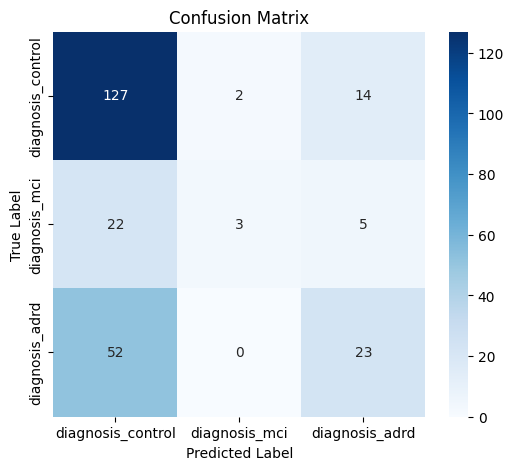


Classification report:
               precision    recall  f1-score   support

           0      0.632     0.888     0.738       143
           1      0.600     0.100     0.171        30
           2      0.548     0.307     0.393        75

    accuracy                          0.617       248
   macro avg      0.593     0.432     0.434       248
weighted avg      0.603     0.617     0.565       248



In [42]:
print_classification_report(baseline_model, X_val, y_val,CLASSES_NAMES)

### Test on new data (Test set) ###

### Improved baseline model (with regularization and dropout) ###

In [43]:
import tensorflow as tf

class VGGNet_Baseline_Regularized_Model(tf.keras.models.Model):
    def __init__(self, classes):
        super(VGGNet_Baseline_Regularized_Model, self).__init__()
        self.num_classes = len(classes)
        L2 = tf.keras.regularizers.l2(1e-5)

        self.conv2D_1 = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same', kernel_regularizer=L2)
        self.maxPooling2D_1 = tf.keras.layers.MaxPooling2D((2, 4))

        self.conv2D_2 = tf.keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same', kernel_regularizer=L2)
        self.maxPooling2D_2 = tf.keras.layers.MaxPooling2D((2, 4))

        self.conv2D_3 = tf.keras.layers.Conv2D(512, (3, 3), activation='relu', padding='same', kernel_regularizer=L2)
        self.maxPooling2D_3 = tf.keras.layers.MaxPooling2D((2, 4))

        self.conv2D_4 = tf.keras.layers.Conv2D(1024, (3, 3), activation='relu', padding='same', kernel_regularizer=L2)
        self.maxPooling2D_4 = tf.keras.layers.MaxPooling2D((3, 5))

        self.conv2D_5 = tf.keras.layers.Conv2D(1024, (1, 1), activation='relu', padding='same', kernel_regularizer=L2)

        self.flatten = tf.keras.layers.Flatten()
        self.dropout = tf.keras.layers.Dropout(0.3)
        self.dense_head = tf.keras.layers.Dense(self.num_classes, activation='softmax')

    def call(self, inputs, training=False):
        x = self.conv2D_1(inputs)
        x = self.maxPooling2D_1(x)

        x = self.conv2D_2(x)
        x = self.maxPooling2D_2(x)

        x = self.conv2D_3(x)
        x = self.maxPooling2D_3(x)

        x = self.conv2D_4(x)
        x = self.maxPooling2D_4(x)

        x = self.conv2D_5(x)
        x = self.flatten(x)
        x = self.dropout(x, training=training)
        return self.dense_head(x)

    def __str__(self):
        return f"VGGNet_Baseline_Regularized_Model(num_classes={self.num_classes})"


### Prepare and train regularized model ###

In [44]:
LEARNING_RATE = 3e-4
NUM_EPOCHS = 25
BATCH_SIZE = 32

optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)
baseline_model_regularized = VGGNet_Baseline_Regularized_Model(classes=('diagnosis_control', 'diagnosis_mci', 'diagnosis_adrd'))
baseline_model_regularized.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=12, restore_best_weights=True), # Increased patience
        tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=4,min_lr=1e-6, verbose=1)
    ]

baseline_model_regularized_train_history = baseline_model_regularized.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=NUM_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks
)

/usr/local/lib/python3.12/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning:

Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.



Epoch 1/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 352ms/step - accuracy: 0.4941 - loss: 1.0456 - val_accuracy: 0.5766 - val_loss: 0.9559 - learning_rate: 3.0000e-04
Epoch 2/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 345ms/step - accuracy: 0.5615 - loss: 0.9882 - val_accuracy: 0.5766 - val_loss: 0.9435 - learning_rate: 3.0000e-04
Epoch 3/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 347ms/step - accuracy: 0.5425 - loss: 0.9773 - val_accuracy: 0.5766 - val_loss: 0.9140 - learning_rate: 3.0000e-04
Epoch 4/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 347ms/step - accuracy: 0.5678 - loss: 0.9422 - val_accuracy: 0.5806 - val_loss: 0.9102 - learning_rate: 3.0000e-04
Epoch 5/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 346ms/step - accuracy: 0.5659 - loss: 0.9372 - val_accuracy: 0.6008 - val_loss: 0.9175 - learning_rate: 3.0000e-04
Epoch 6/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 346ms/step - accuracy: 0.5513 - loss: 0.9634 - val_accuracy: 0.5847 - val_loss: 0.8822 - learning_rate: 3.0000e-04
Epoch 7/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 346ms/step - acc

### Checks ###

In [45]:
preds_train = np.argmax(baseline_model_regularized.predict(X_train), axis=1)
preds_val = np.argmax(baseline_model_regularized.predict(X_val), axis=1)

print("Train predictions:", np.unique(preds_train, return_counts=True))
print("Val predictions:", np.unique(preds_val, return_counts=True))

32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 94ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step
Train predictions: (array([0, 1, 2]), array([845,  50, 115]))
Val predictions: (array([0, 1, 2]), array([202,  10,  36]))


### Compute metrics on validation dataset (no labels for test sample) ###

/usr/local/lib/python3.12/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning:

Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.



8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step
Confusion matrix:



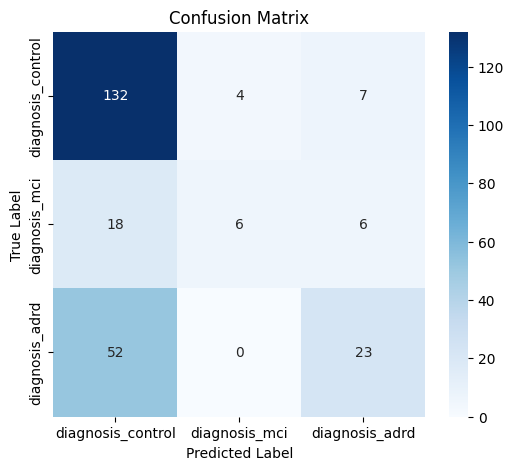


Classification report:
               precision    recall  f1-score   support

           0      0.653     0.923     0.765       143
           1      0.600     0.200     0.300        30
           2      0.639     0.307     0.414        75

    accuracy                          0.649       248
   macro avg      0.631     0.477     0.493       248
weighted avg      0.643     0.649     0.603       248



In [46]:
print_classification_report(baseline_model_regularized, X_val, y_val,CLASSES_NAMES)

### Comparing with baseline ###
- accuracy is better
- improvement for adrd class (alzheimer) in term of recall and f1-score
- improvement for control class in terms of f1-score

### Try regularized baseline model but with class_weights this time ###

In [47]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

from sklearn.utils.class_weight import compute_class_weight
import numpy as np

if y_train.ndim > 1:
    y_train_int = np.argmax(y_train, axis=1)
else:
    y_train_int = y_train

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_int),
    y=y_train_int
)

class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)

class_weight_dict = {i: w for i, w in enumerate(class_weights)}
print("Class weights:", class_weight_dict)


Class weights: {0: np.float64(0.6066066066066066), 1: np.float64(2.337962962962963), 2: np.float64(1.082529474812433)}
Class weights: {0: np.float64(0.6066066066066066), 1: np.float64(2.337962962962963), 2: np.float64(1.082529474812433)}


In [48]:
print("y_train.shape:", y_train.shape)
print("Exemples de y_train[:5]:\n", y_train[:5])

y_train.shape: (1010, 3)
Exemples de y_train[:5]:
 [[1. 0. 0.]
 [0. 0. 1.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 0. 1.]]


In [49]:
tf.config.run_functions_eagerly(True)
optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)
baseline_model_regularized = VGGNet_Baseline_Regularized_Model(classes=('diagnosis_control', 'diagnosis_mci', 'diagnosis_adrd'))
baseline_model_regularized.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

dummy_input = tf.random.normal((1,) + X_train.shape[1:])
baseline_model_regularized.predict(dummy_input)





1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step


/usr/local/lib/python3.12/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning:

Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.



array([[0.35597923, 0.32377034, 0.32025045]], dtype=float32)

In [50]:
baseline_model_regularized_train_history = baseline_model_regularized.fit(
    X_train, y_train,
    epochs=NUM_EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 351ms/step - accuracy: 0.3776 - loss: 1.1514 - val_accuracy: 0.5766 - val_loss: 1.1101 - learning_rate: 3.0000e-04
Epoch 2/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 342ms/step - accuracy: 0.3098 - loss: 1.1371 - val_accuracy: 0.2177 - val_loss: 1.1479 - learning_rate: 3.0000e-04
Epoch 3/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 340ms/step - accuracy: 0.3505 - loss: 1.0785 - val_accuracy: 0.5524 - val_loss: 1.0259 - learning_rate: 3.0000e-04
Epoch 4/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 339ms/step - accuracy: 0.3930 - loss: 1.0572 - val_accuracy: 0.5766 - val_loss: 0.9949 - learning_rate: 3.0000e-04
Epoch 5/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 341ms/step - accuracy: 0.5325 - loss: 1.0160 - val_accuracy: 0.5403 - val_loss: 0.9655 - learning_rate: 3.0000e-04
Epoch 6/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 341ms/step - accuracy: 0.4429 - loss: 1.0144 - val_accuracy: 0.5645 - val_loss: 0.9243 - learning_rate: 3.0000e-04
Epoch 7/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 341ms/step - acc

In [51]:
preds_train = np.argmax(baseline_model_regularized.predict(X_train), axis=1)
preds_val = np.argmax(baseline_model_regularized.predict(X_val), axis=1)

print("Train predictions:", np.unique(preds_train, return_counts=True))
print("Val predictions:", np.unique(preds_val, return_counts=True))

/usr/local/lib/python3.12/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning:

Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.



32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step
Train predictions: (array([0, 1, 2]), array([606, 225, 179]))
Val predictions: (array([0, 1, 2]), array([162,  46,  40]))


### Compute metrics on validation dataset  ###

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step
Confusion matrix:



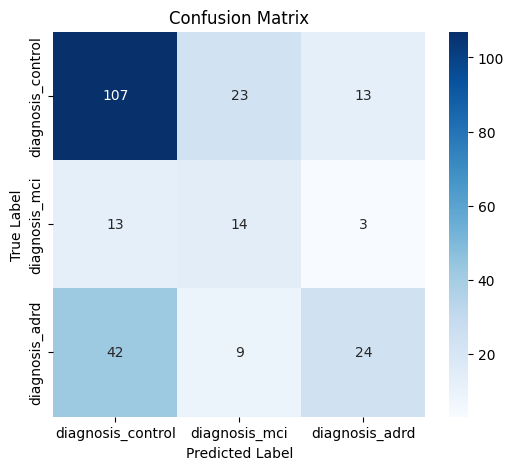


Classification report:
               precision    recall  f1-score   support

           0      0.660     0.748     0.702       143
           1      0.304     0.467     0.368        30
           2      0.600     0.320     0.417        75

    accuracy                          0.585       248
   macro avg      0.522     0.512     0.496       248
weighted avg      0.599     0.585     0.575       248



In [52]:
print_classification_report(baseline_model_regularized, X_val, y_val,CLASSES_NAMES)

### accuracy is lower than those of preceding models ###

### Different Architecture - Transfer Learning based on EfficientNetB0 ###

In [53]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy

# mel_spectogramms pre-processing
def preprocess_mel_for_efficientnet(mel_spectrogram):
    """
    mel_spectrogram : np.array - shape (96, 1366, 1)
    returned shape : (224, 224, 3)
    """
    mel_resized = tf.image.resize(mel_spectrogram, (224, 224))
    mel_rgb = tf.repeat(mel_resized, repeats=3, axis=-1)  # 3 channels required for efficientnet input
    return mel_rgb

# prepare datasets
X_train_rgb = tf.stack([preprocess_mel_for_efficientnet(x) for x in X_train])
X_val_rgb   = tf.stack([preprocess_mel_for_efficientnet(x) for x in X_val])

# EfficientNetB0 Backbone
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3),
    pooling='avg'  # GlobalAveragePooling2D
)

# freeze backbone
base_model.trainable = False

# add classification head 3 classes
inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(len(CLASSES_NAMES), activation='softmax')(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss=CategoricalCrossentropy(),
    metrics=['accuracy']
)

# callbacks
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)
]

# train model
history = model.fit(
    X_train_rgb, y_train,
    validation_data=(X_val_rgb, y_val),
    epochs=50,
    batch_size=32,
    callbacks=callbacks
)


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning:

Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.



32/32 ━━━━━━━━━━━━━━━━━━━━ 24s 740ms/step - accuracy: 0.4603 - loss: 1.0673 - val_accuracy: 0.5766 - val_loss: 0.9485 - learning_rate: 0.0010
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 23s 730ms/step - accuracy: 0.5368 - loss: 0.9811 - val_accuracy: 0.5766 - val_loss: 0.9352 - learning_rate: 0.0010
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 23s 734ms/step - accuracy: 0.5393 - loss: 0.9928 - val_accuracy: 0.5766 - val_loss: 0.9363 - learning_rate: 0.0010
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 23s 732ms/step - accuracy: 0.5403 - loss: 1.0046 - val_accuracy: 0.5766 - val_loss: 0.9451 - learning_rate: 0.0010
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 23s 731ms/step - accuracy: 0.5400 - loss: 0.9764 - val_accuracy: 0.5766 - val_loss: 0.9373 - learning_rate: 0.0010
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 23s 731ms/step - accuracy: 0.5505 - loss: 0.9664 - val_accuracy: 0.5766 - val_loss: 0.9344 - learning_rate: 0.0010
Epoch 7/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 23s 727ms/step - accuracy: 0.5507 - loss: 0.9820 - val_

### Check ###

In [54]:
preds_train = np.argmax(model.predict(X_train_rgb), axis=1)
preds_val = np.argmax(model.predict(X_val_rgb), axis=1)

print("Train predictions:", np.unique(preds_train, return_counts=True))
print("Val predictions:", np.unique(preds_val, return_counts=True))

32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 279ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 280ms/step
Train predictions: (array([0]), array([1010]))
Val predictions: (array([0]), array([248]))


### As we can see above, all model's predictions are dropping in first class (bad) ###

### Different Architecture - Transfer Learning based on VGGish ###

In [8]:
!pip install tensorflow tensorflow_hub librosa scikit-learn tqdm

import os
import numpy as np
import tensorflow as tf
import tensorflow_hub as hub
import librosa
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import confusion_matrix, classification_report
from tqdm import tqdm


In [9]:
SAMPLING_RATE = 16000  # Recommanded for VGGish

# Data augmentation  (train only)
def augment_audio(waveform, sr=SAMPLING_RATE):
    if waveform.ndim > 1:
        waveform = waveform[:,0]
    # Pitch shift
    waveform = librosa.effects.pitch_shift(y=waveform, sr=sr, n_steps=np.random.uniform(-1, 1))

    # Time stretch
    rate = np.random.uniform(0.9, 1.1)
    waveform = librosa.effects.time_stretch(y=waveform, rate=rate)

    # Add noise
    noise = np.random.normal(0, 0.005, len(waveform))
    waveform = waveform + noise
    # Normalize
    waveform = waveform / (np.max(np.abs(waveform)) + 1e-8)
    return waveform

# Prepare VGGish Embeddings
def prepare_dataset(file_paths, labels_dict=None, augment=False,vggish_model=None):

    embeddings = []
    labels = []

    for file_path in tqdm(file_paths, desc="Generating embeddings"):
        if not os.path.exists(file_path):
            continue

        waveform, sr = librosa.load(file_path, sr=SAMPLING_RATE)
        waveform = waveform.astype(np.float32)

        if augment:
            waveform = augment_audio(waveform, sr)

        # VGGish required (N_samples,) waveform float32
        embedding = vggish_model(waveform)
        embedding = tf.reduce_mean(embedding, axis=0).numpy()  # time pooling
        embeddings.append(embedding)

        if labels_dict:
            uid = os.path.splitext(os.path.basename(file_path))[0]
            labels.append(labels_dict.get(uid, -1))

    X = np.array(embeddings)
    y = np.array(labels) if labels else None
    return X, y


def build_dense_model(input_dim, num_classes):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_dim,)),
        tf.keras.layers.Dense(256, activation='relu'),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])
    return model


In [10]:
labels_df["class_id"] = labels_df[CLASSES_NAMES].idxmax(axis=1)
label_map = {
    "diagnosis_control": 0,
    "diagnosis_mci": 1,
    "diagnosis_adrd": 2
}
labels_df["class_id"] = labels_df["class_id"].map(label_map)

In [11]:

labels_dict = {row["uid"]: int(row["class_id"]) for _, row in labels_df.iterrows()}

file_paths = [os.path.join(TRAIN_AUDIOS_WAV_DIR, f"{row['uid']}.wav") for _, row in labels_df.iterrows()]
labels = [labels_dict[os.path.splitext(os.path.basename(fp))[0]] for fp in file_paths]

'''
train_files, val_files, y_train, y_val = train_test_split(
    file_paths, labels, test_size=0.2, random_state=42, stratify=labels
)
'''

train_file_paths, val_file_paths = train_test_split(file_paths, test_size=0.2, random_state=42, stratify=labels)

train_file_paths[:2]

vggish_model_url = "https://tfhub.dev/google/vggish/1"
vggish_model = hub.load(vggish_model_url)

X_train, y_train = prepare_dataset(train_file_paths, labels_dict, augment=True,vggish_model=vggish_model)
X_val, y_val = prepare_dataset(val_file_paths, labels_dict, augment=False,vggish_model=vggish_model)


# One-hot encode
encoder = OneHotEncoder(sparse_output=False)
y_train_cat = encoder.fit_transform(y_train.reshape(-1,1))
y_val_cat = encoder.transform(y_val.reshape(-1,1))

dense_model = build_dense_model(X_train.shape[1], len(CLASSES_NAMES))

dense_model.compile(optimizer=tf.keras.optimizers.Adam(0.001),
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])

Generating embeddings: 100%|██████████| 330/330 [00:07<00:00, 43.27it/s]


In [12]:
unique, counts = np.unique(np.argmax(y_train_cat, axis=1), return_counts=True)
print(dict(zip(unique, counts)))


{np.int64(0): np.int64(728), np.int64(1): np.int64(174), np.int64(2): np.int64(414)}


### Train model ###

In [13]:
BATCH_SIZE =32
NUM_EPOCHS=50

vggish_model_history = dense_model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=NUM_EPOCHS,
    batch_size=BATCH_SIZE
)

Epoch 1/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 9s 136ms/step - accuracy: 0.4868 - loss: 0.9972 - val_accuracy: 0.5545 - val_loss: 0.9572
Epoch 2/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5420 - loss: 0.9427 - val_accuracy: 0.5545 - val_loss: 0.9433
Epoch 3/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5514 - loss: 0.9371 - val_accuracy: 0.5545 - val_loss: 0.9357
Epoch 4/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5076 - loss: 0.9579 - val_accuracy: 0.5545 - val_loss: 0.9705
Epoch 5/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5610 - loss: 0.9113 - val_accuracy: 0.5545 - val_loss: 0.9494
Epoch 6/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5751 - loss: 0.9205 - val_accuracy: 0.5515 - val_loss: 0.9377
Epoch 7/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5662 - loss: 0.8970 - val_accuracy: 0.5545 - val_loss: 0.9637
Epoch 8/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5599 - loss: 0.9056 - val_accuracy: 0.5485 - val_los

### Compute metrics on validation dataset ###

In [14]:
# Predictions
y_pred = np.argmax(dense_model.predict(X_val), axis=1)
y_true = np.argmax(y_val_cat, axis=1)

print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred, digits=3))

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step
Confusion Matrix:
 [[178   0   5]
 [ 43   0   0]
 [100   0   4]]
              precision    recall  f1-score   support

           0      0.555     0.973     0.706       183
           1      0.000     0.000     0.000        43
           2      0.444     0.038     0.071       104

    accuracy                          0.552       330
   macro avg      0.333     0.337     0.259       330
weighted avg      0.448     0.552     0.414       330



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Model is not able to detect class 1. In addition f1-score is very bad for adrd class ###

### Try to improve predictions with class_weight to manage imbalance  ###

In [15]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.utils.class_weight import compute_class_weight

y_int = np.argmax(y_train_cat, axis=1)
class_weights = compute_class_weight('balanced', classes=np.unique(y_int), y=y_int)
class_weight_dict = {i: w*1.5 for i, w in enumerate(class_weights)}


callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)
]

dense_model = build_dense_model(X_train.shape[1], len(CLASSES_NAMES))

dense_model.compile(optimizer=tf.keras.optimizers.Adam(0.001),
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])

vggish_model_history = dense_model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=50,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 6s 74ms/step - accuracy: 0.3854 - loss: 1.6600 - val_accuracy: 0.3636 - val_loss: 1.1013 - learning_rate: 0.0010
Epoch 2/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3734 - loss: 1.5896 - val_accuracy: 0.3333 - val_loss: 1.1315 - learning_rate: 0.0010
Epoch 3/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4241 - loss: 1.6285 - val_accuracy: 0.4636 - val_loss: 1.0765 - learning_rate: 0.0010
Epoch 4/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3843 - loss: 1.5565 - val_accuracy: 0.4667 - val_loss: 1.0310 - learning_rate: 0.0010
Epoch 5/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4686 - loss: 1.5444 - val_accuracy: 0.5394 - val_loss: 1.0113 - learning_rate: 0.0010
Epoch 6/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4401 - loss: 1.6025 - val_accuracy: 0.5152 - val_loss: 1.0108 - learning_rate: 0.0010
Epoch 7/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4484 - loss: 1.4918 - val_accuracy:

### Compute metrics on validation dataset ###

In [16]:
# Pedictions
y_pred = np.argmax(dense_model.predict(X_val), axis=1)
y_true = np.argmax(y_val_cat, axis=1)

print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred, digits=3))


11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step
Confusion Matrix:
 [[178   3   2]
 [ 40   2   1]
 [ 98   4   2]]
              precision    recall  f1-score   support

           0      0.563     0.973     0.713       183
           1      0.222     0.047     0.077        43
           2      0.400     0.019     0.037       104

    accuracy                          0.552       330
   macro avg      0.395     0.346     0.276       330
weighted avg      0.467     0.552     0.417       330



### Bad f1-score on class 1 and 2 ###

###